# 🐱🐶 Cat vs Dog Classification — Transfer Learning (MobileNetV2)

**Model:** MobileNetV2 pretrained on ImageNet + Custom Head  
**Dataset:** 6,000 images (3,000 cats / 3,000 dogs)  
**Split:** 70% Train / 15% Validation / 15% Test  

---

### Pipeline Overview
| Phase | What Happens |
|---|---|
| Phase 1 | Load MobileNetV2 without top head, freeze all base layers |
| Phase 2 | Add custom head: Flatten → Dense → Dropout → Output |
| Phase 3 | Train custom head only (base frozen) |
| Phase 4 | Unfreeze last 30 layers of base, fine-tune with low LR |

## Setup — Mount Drive & Unzip Project

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/final_img_project.zip', 'r') as z:
    z.extractall('/content/')
print('✅ Done!')

✅ Done!


## Section 1 — Import Libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Flatten, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)

print(f'TensorFlow  : {tf.__version__}')
print(f'GPU         : {tf.config.list_physical_devices("GPU")}')

TensorFlow  : 2.20.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Section 2 — Paths & Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR    = Path('/content/final_img_project')
SPLIT_DIR   = BASE_DIR / 'data' / 'split'
MODELS_DIR  = BASE_DIR / 'models'
RESULTS_DIR = BASE_DIR / 'results'

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS_HEAD   = 10   # Phase 1: train head only
EPOCHS_FINETUNE = 10 # Phase 2: fine-tune last layers
LR_HEAD       = 0.001
LR_FINETUNE   = 0.0001  # much lower for fine-tuning
SEED          = 42

print('Paths configured successfully')
print(f'Train : {len(os.listdir(SPLIT_DIR/"train"/"cats")) + len(os.listdir(SPLIT_DIR/"train"/"dogs"))} images')
print(f'Val   : {len(os.listdir(SPLIT_DIR/"val"/"cats")) + len(os.listdir(SPLIT_DIR/"val"/"dogs"))} images')
print(f'Test  : {len(os.listdir(SPLIT_DIR/"test"/"cats")) + len(os.listdir(SPLIT_DIR/"test"/"dogs"))} images')

Paths configured successfully
Train : 4200 images
Val   : 900 images
Test  : 900 images


## Section 3 — Load Data

In [ ]:
datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = datagen.flow_from_directory(
    SPLIT_DIR / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)

val_gen = datagen.flow_from_directory(
    SPLIT_DIR / 'val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)

test_gen = datagen.flow_from_directory(
    SPLIT_DIR / 'test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED
)

print(f'Class indices: {train_gen.class_indices}')

Found 4200 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Class indices: {'cats': 0, 'dogs': 1}


## Section 4 — Load MobileNetV2 Base (Without Top Head)

We load MobileNetV2 pretrained on ImageNet **without the top classification head** (`include_top=False`).  
This gives us a powerful feature extractor trained on 1.2 million images.

In [ ]:
# Load MobileNetV2 WITHOUT the top classification head
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,       # remove the original classification head
    weights='imagenet'       # use pretrained ImageNet weights
)

# Freeze ALL base layers — we don't want to change pretrained weights yet
base_model.trainable = False

print(f'Base model loaded: {base_model.name}')
print(f'Total layers in base: {len(base_model.layers)}')
print(f'Base model trainable: {base_model.trainable}')
print(f'Trainable parameters: {sum([tf.size(w).numpy() for w in base_model.trainable_weights])}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model loaded: mobilenetv2_1.00_224
Total layers in base: 154
Base model trainable: False
Trainable parameters: 0


## Section 5 — Add Custom Classification Head

We explicitly add our own head on top of the frozen base:  
`GlobalAveragePooling2D → Dense(256) → Dropout(0.5) → Dense(1, sigmoid)`

Every layer is manually defined — no drag and drop!

In [ ]:
# ── Build the full model manually ──────────────────────────────────────

# Input goes into the frozen base
x = base_model.output

# GlobalAveragePooling — converts feature maps to a 1D vector
x = GlobalAveragePooling2D(name='global_avg_pool')(x)

# Dense layer — learns cat/dog specific features
x = Dense(256, activation='relu', name='custom_dense_1')(x)

# Dropout — prevents overfitting
x = Dropout(0.5, name='custom_dropout')(x)

# Output layer — Sigmoid for binary classification
output = Dense(1, activation='sigmoid', name='output')(x)

# Create the full model
model = Model(inputs=base_model.input, outputs=output, name='TransferLearning_MobileNetV2')

print('Custom head added successfully!')
print(f'Total layers: {len(model.layers)}')
print(f'Total params: {model.count_params():,}')
print(f'Trainable params (head only): {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

Custom head added successfully!
Total layers: 158
Total params: 2,586,177
Trainable params (head only): 328,193


## Section 6 — Phase 1: Train Custom Head Only

Base layers are **frozen** — only our custom head layers are trained.

In [ ]:
# Compile with higher learning rate for head training
model.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        filepath=str(MODELS_DIR / 'tl_best_phase1.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print('Phase 1 — Training custom head only (base frozen)...')
history_phase1 = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

print(f'\nPhase 1 complete!')
print(f'Best val accuracy: {max(history_phase1.history["val_accuracy"]):.4f}')

Phase 1 — Training custom head only (base frozen)...
Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9364 - loss: 0.1541
Epoch 1: val_accuracy improved from None to 0.98000, saving model to /content/final_img_project/models/tl_best_phase1.keras

Epoch 1: finished saving model to /content/final_img_project/models/tl_best_phase1.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 65s 327ms/step - accuracy: 0.9657 - loss: 0.0975 - val_accuracy: 0.9800 - val_loss: 0.0534 - learning_rate: 0.0010
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9822 - loss: 0.0498
Epoch 2: val_accuracy did not improve from 0.98000
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9798 - loss: 0.0557 - val_accuracy: 0.9756 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9846 - loss: 0.0407
Epoch 3: val_accuracy improved from 0.98000 to 0.98222, saving model to /content/final_img_project/models/tl_best_phase1.keras

Epoch

## Section 7 — Phase 2: Unfreeze Last 30 Layers for Fine-Tuning

Now we unfreeze the last 30 layers of MobileNetV2 and train with a very low learning rate.  
This allows the base model to slightly adapt to our cat/dog dataset.

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Count trainable layers
trainable_layers = sum(1 for layer in model.layers if layer.trainable)
print(f'Trainable layers after unfreezing: {trainable_layers}')
print(f'Trainable params now: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

# Recompile with MUCH lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=LR_FINETUNE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        filepath=str(MODELS_DIR / 'tl_best_final.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print('\nPhase 2 — Fine-tuning last 30 layers with low learning rate...')
history_phase2 = model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)

print(f'\nPhase 2 complete!')
print(f'Best val accuracy: {max(history_phase2.history["val_accuracy"]):.4f}')

Trainable layers after unfreezing: 34
Trainable params now: 1,854,593

Phase 2 — Fine-tuning last 30 layers with low learning rate...
Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9476 - loss: 0.1854
Epoch 1: val_accuracy improved from None to 0.97556, saving model to /content/final_img_project/models/tl_best_final.keras

Epoch 1: finished saving model to /content/final_img_project/models/tl_best_final.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 49s 227ms/step - accuracy: 0.9638 - loss: 0.1145 - val_accuracy: 0.9756 - val_loss: 0.0777 - learning_rate: 1.0000e-04
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9884 - loss: 0.0340
Epoch 2: val_accuracy did not improve from 0.97556
132/132 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.9900 - loss: 0.0275 - val_accuracy: 0.9744 - val_loss: 0.1019 - learning_rate: 1.0000e-04
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9954 - loss: 0.0146
Epoch 3: ReduceLROnPlateau reducing learning r

## Section 8 — Training Curves (Both Phases)

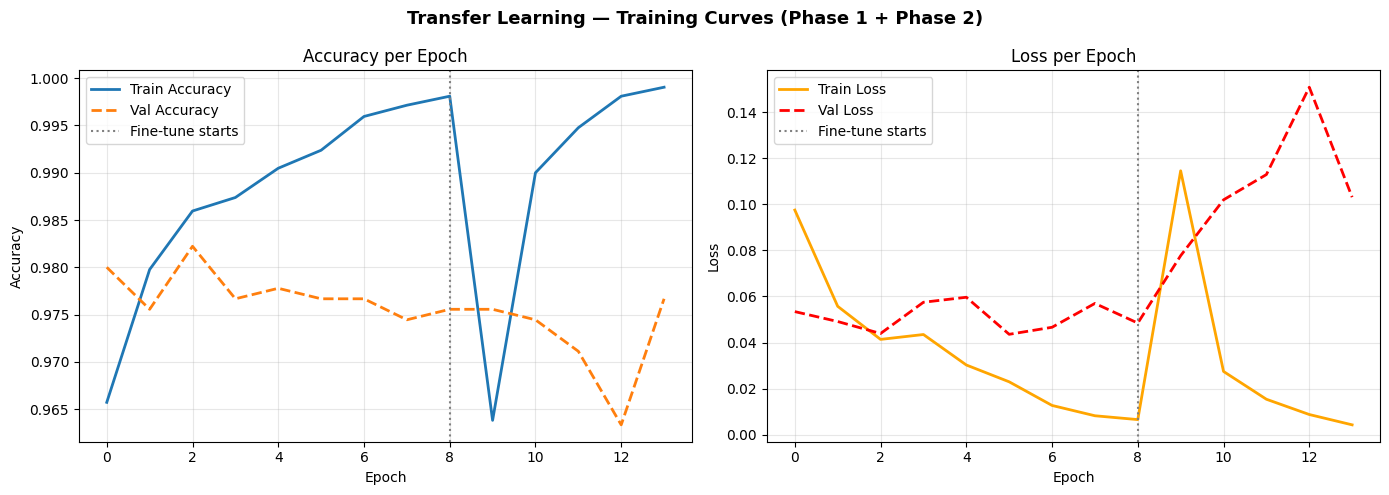

Saved: tl_training_curves.png


In [ ]:
# Combine both phases
acc     = history_phase1.history['accuracy']     + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss    = history_phase1.history['loss']         + history_phase2.history['loss']
val_loss= history_phase1.history['val_loss']     + history_phase2.history['val_loss']

phase1_epochs = len(history_phase1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transfer Learning — Training Curves (Phase 1 + Phase 2)', fontsize=13, fontweight='bold')

# Accuracy
axes[0].plot(acc,     label='Train Accuracy', linewidth=2)
axes[0].plot(val_acc, label='Val Accuracy',   linewidth=2, linestyle='--')
axes[0].axvline(x=phase1_epochs-1, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune starts')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(loss,     label='Train Loss', linewidth=2, color='orange')
axes[1].plot(val_loss, label='Val Loss',   linewidth=2, linestyle='--', color='red')
axes[1].axvline(x=phase1_epochs-1, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune starts')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tl_training_curves.png')

## Section 9 — Evaluate on Test Set

In [ ]:
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
y_true      = test_gen.classes

print('\n' + '='*55)
print('        CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step

        CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Cat       0.99      0.97      0.98       450
         Dog       0.97      0.99      0.98       450

    accuracy                           0.98       900
   macro avg       0.98      0.98      0.98       900
weighted avg       0.98      0.98      0.98       900



## Section 10 — Confusion Matrix

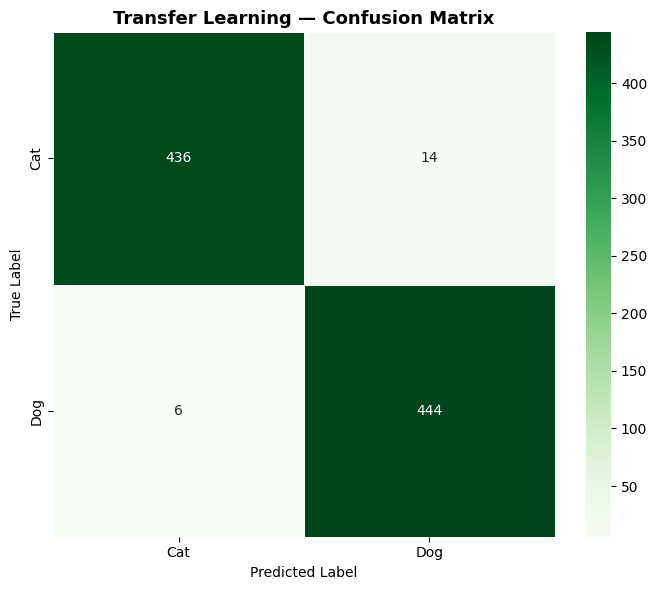

Saved: tl_confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog'],
    linewidths=0.5
)
plt.title('Transfer Learning — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tl_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tl_confusion_matrix.png')

## Section 11 — ROC / AUC Curve

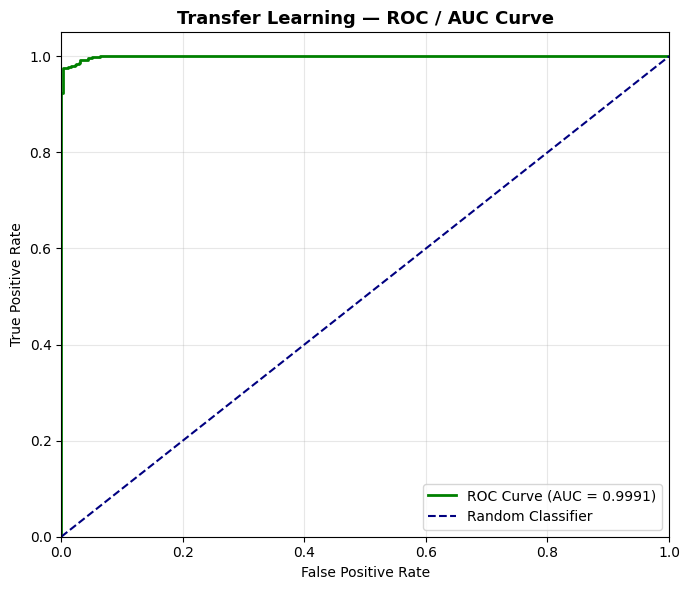

AUC Score: 0.9991
Saved: tl_roc_curve.png


In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='green', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linewidth=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Transfer Learning — ROC / AUC Curve', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tl_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC Score: {roc_auc:.4f}')
print('Saved: tl_roc_curve.png')

## Section 12 — Sample Predictions

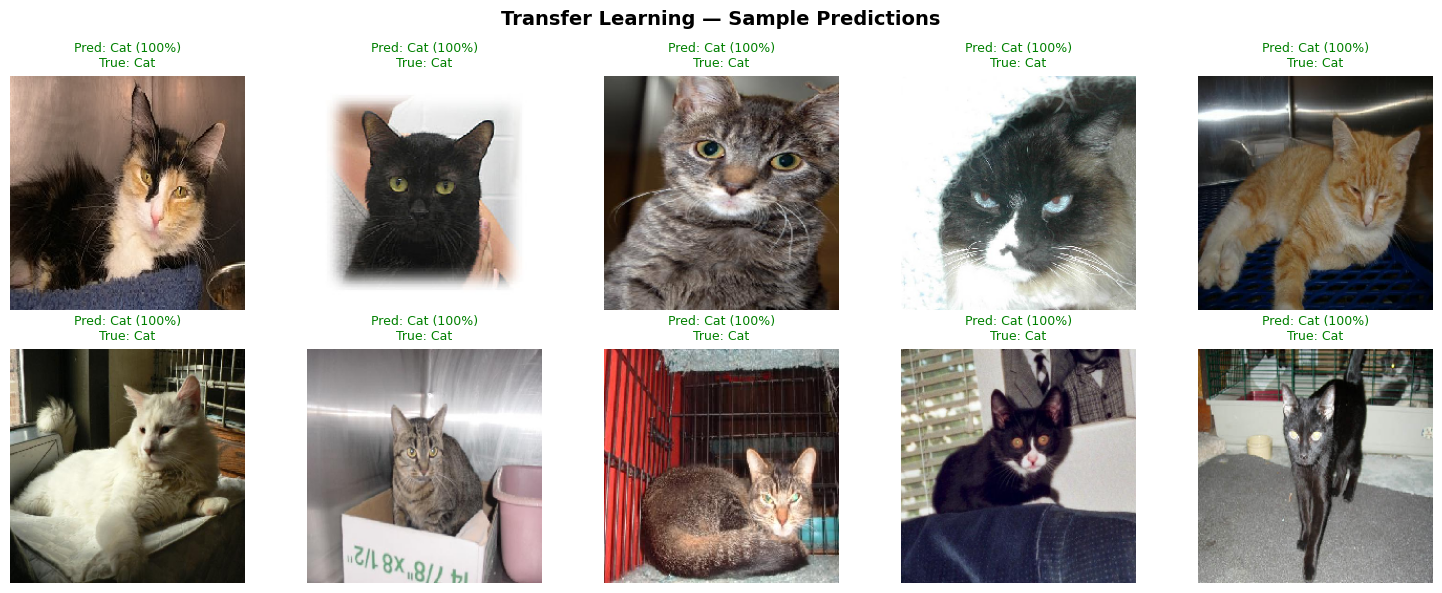

Saved: tl_sample_predictions.png


In [ ]:
test_gen.reset()
images, labels = next(test_gen)
preds = model.predict(images, verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Transfer Learning — Sample Predictions', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    pred_label = 'Dog' if preds[i] > 0.5 else 'Cat'
    true_label = 'Dog' if labels[i] == 1  else 'Cat'
    confidence = preds[i][0] if preds[i] > 0.5 else 1 - preds[i][0]
    color      = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'Pred: {pred_label} ({confidence:.0%})\nTrue: {true_label}', fontsize=9, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tl_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tl_sample_predictions.png')

## Section 13 — Save Model & Final Summary

In [ ]:
model.save(MODELS_DIR / 'tl_final.keras')
print('Model saved to models/tl_final.keras')

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print('\n' + '='*45)
print('   TRANSFER LEARNING — FINAL RESULTS')
print('='*45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC       : {roc_auc:.4f}')
print('='*45)

Model saved to models/tl_final.keras

   TRANSFER LEARNING — FINAL RESULTS
  Accuracy  : 0.9778  (97.78%)
  Precision : 0.9694
  Recall    : 0.9867
  F1-Score  : 0.9780
  AUC       : 0.9991


## Section 14 — Model Comparison Table

Update the CNN results below with your actual CNN from Scratch results.

In [ ]:
# ── CNN from Scratch results (from previous notebook) ─────────────────
cnn_results = {
    'Accuracy' : 0.7422,
    'Precision': 0.7206,
    'Recall'   : 0.7911,
    'F1-Score' : 0.7542,
    'AUC'      : 0.8320
}

# ── Transfer Learning results ──────────────────────────────────────────
tl_results = {
    'Accuracy' : acc,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1,
    'AUC'      : roc_auc
}

print('\n' + '='*60)
print('           MODEL COMPARISON TABLE')
print('='*60)
print(f'{"Metric":<15} {"CNN from Scratch":>18} {"Transfer Learning":>18}')
print('-'*60)
for metric in cnn_results:
    cnn_val = cnn_results[metric]
    tl_val  = tl_results[metric]
    better  = '✅' if tl_val > cnn_val else ''
    print(f'{metric:<15} {cnn_val:>18.4f} {tl_val:>18.4f} {better}')
print('='*60)
print('\n✅ = Transfer Learning is better')


           MODEL COMPARISON TABLE
Metric            CNN from Scratch  Transfer Learning
------------------------------------------------------------
Accuracy                    0.7422             0.9778 ✅
Precision                   0.7206             0.9694 ✅
Recall                      0.7911             0.9867 ✅
F1-Score                    0.7542             0.9780 ✅
AUC                         0.8320             0.9991 ✅

✅ = Transfer Learning is better


## Section 15 — Download Results

In [ ]:
from google.colab import files
import shutil

shutil.make_archive('/content/tl_models',  'zip', '/content/final_img_project/models')
shutil.make_archive('/content/tl_results', 'zip', '/content/final_img_project/results')

files.download('/content/tl_models.zip')
files.download('/content/tl_results.zip')
print('✅ Downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!
